In [22]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from typing import List
from langgraph.checkpoint.memory import MemorySaver

In [23]:
llm = ChatOllama(
    model="llama3.2:3b"
)
llm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2:3b')

In [24]:
# llm = ChatGoogleGenerativeAI(model="chat-bison@001")
# llm

In [25]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [26]:
def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

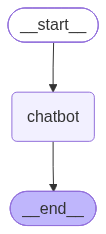

In [42]:
checkpoint = MemorySaver()

graph_builder = StateGraph(ChatState)

# Add the chatbot node to the graph
graph_builder.add_node("chatbot", chat_node)

# Connect the start and end nodes to the chatbot node
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph
chat_bot= graph_builder.compile(checkpointer=checkpoint)
chat_bot

In [30]:
# Run without checkpointer
initial_state = {
    "messages" : [HumanMessage(content="What is Encapsulation in OOp Python?")]
}

response = chat_bot.invoke(initial_state)

In [31]:
response

{'messages': [HumanMessage(content='What is Encapsulation in OOp Python?', additional_kwargs={}, response_metadata={}, id='df2cff60-d86c-4220-903d-41d21864450d'),
  AIMessage(content='Encapsulation in Object-Oriented Programming (OOP) is a fundamental concept that binds together the data and the methods that manipulate that data. It\'s a way to hide the implementation details of an object from the outside world and only expose the necessary information through a controlled interface.\n\nIn Python, encapsulation is achieved by using classes and objects. A class is a blueprint for creating objects, and an object is an instance of a class.\n\nHere are the key elements of encapsulation in Python:\n\n1.  **Data Hiding**: Encapsulation hides the internal data of an object from the outside world. This data is not directly accessible from outside the object.\n2.  **Access Control**: Encapsulation provides access control to the internal data of an object. You can specify which methods can acces

In [32]:
response["messages"][-1].content

'Encapsulation in Object-Oriented Programming (OOP) is a fundamental concept that binds together the data and the methods that manipulate that data. It\'s a way to hide the implementation details of an object from the outside world and only expose the necessary information through a controlled interface.\n\nIn Python, encapsulation is achieved by using classes and objects. A class is a blueprint for creating objects, and an object is an instance of a class.\n\nHere are the key elements of encapsulation in Python:\n\n1.  **Data Hiding**: Encapsulation hides the internal data of an object from the outside world. This data is not directly accessible from outside the object.\n2.  **Access Control**: Encapsulation provides access control to the internal data of an object. You can specify which methods can access or modify the data.\n3.  **Abstraction**: Encapsulation provides abstraction, which is the ability to show only the necessary information to the outside world while hiding the inter

In [ ]:
config = {"configurable" : {"thread_id" : "thread-1"}}

while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit", "bye"]:
        break
    config = {"configurable" : {"thread_id" : "thread-1"}}
    response = chat_bot.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    print("AI:", response["messages"][-1].content)

AI: Hello Taufiq! Nice to meet you too! It's great to have you here. Is there anything I can help you with or would you like to chat?
AI: At the very beginning, when we started chatting, you said: "hello my name is taufiq nice to meet you".

You introduced yourself with a friendly message!


# Memorize

## Thread InMemorySaver

In [44]:
config = {"configurable" : {"thread_id" : "thread-2"}}

initial_state = {
    "messages" : [HumanMessage(content="Halo nama saya taufiq?")]
}

response = chat_bot.invoke(initial_state, config=config)

In [45]:
response["messages"][-1].content

'Halo Taufiq! Senang bertemu denganmu. Bagaimana kabar hari ini?'

In [46]:
config = {"configurable" : {"thread_id" : "thread-2"}}

initial_state = {
    "messages" : [HumanMessage(content="siapakah nama saya?")]
}

response = chat_bot.invoke(initial_state, config=config)

In [47]:
response["messages"][-1].content

'Maaf, saya lupa! Kamu menyebutkan nama kamu sendiri, yaitu Taufiq. Saya rasa kita belum sempat berbicara tentang apa pun, ya? Apakah kamu ingin berbicara tentang sesuatu yang spesifik atau hanya ingin melakukan percakapan santai?'

In [50]:
chat_bot.get_state(config={"configurable" : {"thread_id" : "thread-2"}})

StateSnapshot(values={'messages': [HumanMessage(content='Halo nama saya taufiq?', additional_kwargs={}, response_metadata={}, id='d0e06b9f-1127-4c82-af47-1896ab4a6301'), AIMessage(content='Halo Taufiq! Senang bertemu denganmu. Bagaimana kabar hari ini?', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-08-25T23:55:54.2947499Z', 'done': True, 'done_reason': 'stop', 'total_duration': 947628300, 'load_duration': 5335500, 'prompt_eval_count': 33, 'prompt_eval_duration': 307990000, 'eval_count': 22, 'eval_duration': 596468000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--01a03b5a-1080-7373-bae6-75c898def031-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 33, 'output_tokens': 22, 'total_tokens': 55}), HumanMessage(content='siapakah nama saya?', additional_kwargs={}, response_metadata={}, id='5c52ba8b-5d33-44ee-9c69-e4a6991dee1b'), AIMessage(content='Maaf, saya lupa! Kamu menyebutkan nama 

In [49]:
state = chat_bot.get_state(config={"configurable" : {"thread_id" : "thread-2"}})

state.values.get("messages")

[HumanMessage(content='Halo nama saya taufiq?', additional_kwargs={}, response_metadata={}, id='d0e06b9f-1127-4c82-af47-1896ab4a6301'),
 AIMessage(content='Halo Taufiq! Senang bertemu denganmu. Bagaimana kabar hari ini?', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-08-25T23:55:54.2947499Z', 'done': True, 'done_reason': 'stop', 'total_duration': 947628300, 'load_duration': 5335500, 'prompt_eval_count': 33, 'prompt_eval_duration': 307990000, 'eval_count': 22, 'eval_duration': 596468000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--01a03b5a-1080-7373-bae6-75c898def031-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 33, 'output_tokens': 22, 'total_tokens': 55}),
 HumanMessage(content='siapakah nama saya?', additional_kwargs={}, response_metadata={}, id='5c52ba8b-5d33-44ee-9c69-e4a6991dee1b'),
 AIMessage(content='Maaf, saya lupa! Kamu menyebutkan nama kamu sendiri, yaitu Taufiq. Say

In [53]:
messages_history = []

for message in state.values.get("messages"):
    # Check whether the message was sent by the user
    if isinstance(message, HumanMessage):
        role = "user"

    # Check whether the message was sent by the AI
    elif isinstance(message, AIMessage):
        role = "assistant"

    # Ignore other message types, such as ToolMessage
    else:
        continue

    messages_history.append((role, message.content))

print(messages_history)

[('user', 'Halo nama saya taufiq?'), ('assistant', 'Halo Taufiq! Senang bertemu denganmu. Bagaimana kabar hari ini?'), ('user', 'siapakah nama saya?'), ('assistant', 'Maaf, saya lupa! Kamu menyebutkan nama kamu sendiri, yaitu Taufiq. Saya rasa kita belum sempat berbicara tentang apa pun, ya? Apakah kamu ingin berbicara tentang sesuatu yang spesifik atau hanya ingin melakukan percakapan santai?')]


## SQLiteSaver

In [65]:
initial_state = {"messages": "hi my names taufiq"}

config1 = {"configurable": {"thread_id" :"thread-1"}}

chat_bot.invoke(initial_state, config = config1)

{'messages': [HumanMessage(content='hi my names taufiq', additional_kwargs={}, response_metadata={}, id='2b3db9a6-40f0-4cfc-99c1-18148ed551f4'),
  AIMessage(content="Hello Taufiq! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-08-26T00:28:50.0902569Z', 'done': True, 'done_reason': 'stop', 'total_duration': 804975500, 'load_duration': 2117700, 'prompt_eval_count': 31, 'prompt_eval_duration': 152322000, 'eval_count': 28, 'eval_duration': 647093000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--01a03b78-3704-73f3-ad02-6690719e8cb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 31, 'output_tokens': 28, 'total_tokens': 59})]}

In [66]:
chat_bot.get_state(config = config1)

StateSnapshot(values={'messages': [HumanMessage(content='hi my names taufiq', additional_kwargs={}, response_metadata={}, id='2b3db9a6-40f0-4cfc-99c1-18148ed551f4'), AIMessage(content="Hello Taufiq! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-08-26T00:28:50.0902569Z', 'done': True, 'done_reason': 'stop', 'total_duration': 804975500, 'load_duration': 2117700, 'prompt_eval_count': 31, 'prompt_eval_duration': 152322000, 'eval_count': 28, 'eval_duration': 647093000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--01a03b78-3704-73f3-ad02-6690719e8cb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 31, 'output_tokens': 28, 'total_tokens': 59})]}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a0e51-be17-6b01-8001-d17a8fff664d'}}, metadata={'sou

In [67]:
list(chat_bot.get_state_history(config1))

[StateSnapshot(values={'messages': [HumanMessage(content='hi my names taufiq', additional_kwargs={}, response_metadata={}, id='2b3db9a6-40f0-4cfc-99c1-18148ed551f4'), AIMessage(content="Hello Taufiq! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-08-26T00:28:50.0902569Z', 'done': True, 'done_reason': 'stop', 'total_duration': 804975500, 'load_duration': 2117700, 'prompt_eval_count': 31, 'prompt_eval_duration': 152322000, 'eval_count': 28, 'eval_duration': 647093000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--01a03b78-3704-73f3-ad02-6690719e8cb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 31, 'output_tokens': 28, 'total_tokens': 59})]}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a0e51-be17-6b01-8001-d17a8fff664d'}}, metadata={'so